# Parity Phase Gates via CPhase and $R_Z$

We collect closed-form expansions of parity phase gates of the form
\begin{equation}
U_n(\theta) = e^{-i \gamma Z_1 Z_2 \cdots Z_n},
\end{equation}
using only
  - single-qubit $R_Z$ rotations, and
  - multi-qubit controlled-phase (CPhase) gates acting on two or more qubits.
All global phases are dropped throughout.

## Preliminaries

We use the single-qubit $Z$ rotation
\begin{equation}
R_Z(\phi) = e^{-i \frac{\phi}{2} Z},
\end{equation}
and define a $k$-qubit controlled-phase gate ($k \ge 2$) acting on a subset
$S = \{i_1,\dots,i_k\}$ of qubits as
\begin{equation}
\mathrm{CP}^{(k)}_S(\phi)
=
\exp\!\left(
i \phi \, |1\cdots1\rangle\langle 1\cdots1|_S
\right).
\end{equation}

The construction relies on expressing Pauli-$Z$ operators in terms of
projectors onto the computational state $|1\rangle$. Using
\begin{equation}
|1\rangle\langle 1| = \frac{1}{2}(I - Z),
\end{equation}
a Pauli-$Z$ string can be written as
\begin{equation}
Z_1 Z_2 \cdots Z_n
=
\prod_{i=1}^{n} (I - 2 P_i),
\qquad
P_i = |1\rangle\langle 1|_i.
\end{equation}

Expanding this product yields
\begin{equation}
Z_1 \cdots Z_n
=
\sum_{k=0}^{n}
(-1)^k 2^k
\sum_{\substack{S \subseteq \{1,\dots,n\} \\ |S| = k}}
P_S,
\qquad
P_S = |1\cdots1\rangle\langle1\cdots1|_S,
\end{equation}
which directly leads, upon exponentiation, to a product of commuting phase
gates: single-qubit $R_Z$ rotations from the $k=1$ terms and $k$-qubit
controlled-phase gates for $k \ge 2$.

## Multi-qubit formula

For the general $n$-qubit parity operator, the resulting decomposition reads
\begin{align}
U_n(\theta)
&=
\prod_{i=1}^{n} R_Z^{(i)}(-2\gamma)
\nonumber\\
&\quad\times
\prod_{k=2}^{n}
\prod_{\substack{S \subseteq \{1,\dots,n\} \\ |S| = k}}
\mathrm{CP}^{(k)}_S\!\left(
(-1)^k 2^k \gamma
\right).
\end{align}

As a concrete example, for $n=3$ one obtains
\begin{align}
e^{-i \gamma Z_1 Z_2 Z_3}
&=
R_Z^{(1)}(-2\gamma)\,
R_Z^{(2)}(-2\gamma)\,
R_Z^{(3)}(-2\gamma)
\nonumber\\
&\quad\times
\mathrm{CP}_{12}(4\gamma)\,
\mathrm{CP}_{13}(4\gamma)\,
\mathrm{CP}_{23}(4\gamma)
\nonumber\\
&\quad\times
\mathrm{CP}_{123}(-8\gamma).
\end{align}

The numerical coefficients ($-2, 4, -8, \dots$) arise from the powers of two in
the projector expansion and alternate in sign according to the
inclusion--exclusion principle.

Interestingly, at the special value $\gamma=\pi/4$, corresponding to the
maximally entangling parity phase gate, all controlled-phase gates acting on
three or more qubits acquire phases that are integer multiples of $2\pi$ and
thus reduce to identities. As a result, $U_n(\pi/4)$ can be realized entirely
using single-qubit $R_Z$ gates and two-qubit $\mathrm{CP}(\pi)=\mathrm{CZ}$ gates,
whereas any deviation from $\gamma=\pi/4$ necessarily reintroduces genuine
many-body controlled-phase interactions.

## Fixed–Target-Phase Optimization of the Parity Gate

We seek the shortest-duration pulse that implements a three-atom parity gate in the strong Rydberg blockade regime, using a fixed set of 10 pulse parameters. To this end, we carry out multiple random initializations of the pulse parameters, optimize each candidate pulse, and select the fastest one that achieves a gate fidelity exceeding the target threshold.

First, we create the target gate object. The Rydberg decay strength is set to $10^{-4}$ and we assume that the atoms interact with the strength of $V_{nn}=V_{nnn}=32$.

In [1]:
# %pip install -q --progress-bar off rydopt # Uncomment for installation on Colab

import rydopt as ro
import numpy as np

phase = np.pi / 4
gate = ro.gates.ThreeQubitGateIsosceles(
    phi=None,
    theta=4 * phase,
    theta_prime=4 * phase,
    lamb=-8 * phase,
    Vnn=32,
    Vnnn=32,
    decay=0.0001,
)

Next, we create the pulse ansatz and specify upper and lower bounds for the random initialization of pulse parameters.

In [2]:
# Pulse ansatz: constant detuning, sweep of the laser phase according to
# sin_crab ansatz
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
)

# Bounds for the initial pulse parameter guesses
n_params = 10
min_initial_params = (15, [-1], -2 * np.ones(n_params), [1.0])
max_initial_params = (20, [1], 2 * np.ones(n_params), [1.0])

Perform 800 random parameter initializations, running in parallel on 4 CPU cores.

In [3]:
opt_result = ro.optimization.multi_start_optimize(
    gate,
    pulse_ansatz,
    min_initial_params,
    max_initial_params,
    tol=1e-6,
    num_initializations=800,
    num_steps=100,
    num_processes=4,
    return_history=True,
)

Started optimization using 4 processes



proc01:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc03:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc02:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc00:   0%|                                           | 0/100 [00:00<?, ?it/s]


=== Optimization finished using multi-start Adam ===

Runtime: 291.565 seconds
Gates with infidelity below tol=1.0e-06: 0

Best gate:
> infidelity = 6.237796e-04
> parameters = (16.68653151155332, [-0.35694484], [ 0.30513845 -0.09840683 -0.36472767  0.14598829  0.50736708  0.47638205
  2.05977995 -0.0988135  -1.10906493 -0.32514304], [1.])
> duration = 16.68653151155332


We plot the history of all optimization runs;

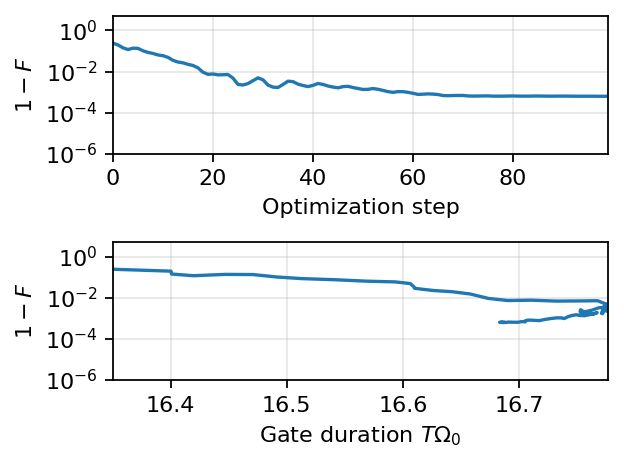

In [4]:
ro.characterization.plot_optimization_history(opt_result);

Also, we analyze the best performing gate;

In [5]:
optimized_params = opt_result.params
infidelity, infidelity_nodecay, ryd_time = ro.characterization.analyze_gate(
    gate, pulse_ansatz, optimized_params, tol=1e-10
)

print(f"Gate infidelity:             {infidelity:.4e}")
print(f"Gate infidelity (no decay):  {infidelity_nodecay:.4e}")
print(f"Rydberg time:                {ryd_time:.4f}")

Gate infidelity:             6.2385e-04
Gate infidelity (no decay):  5.2087e-06
Rydberg time:                6.1886


Finally, we plot the optimal pulse and its spectrum.

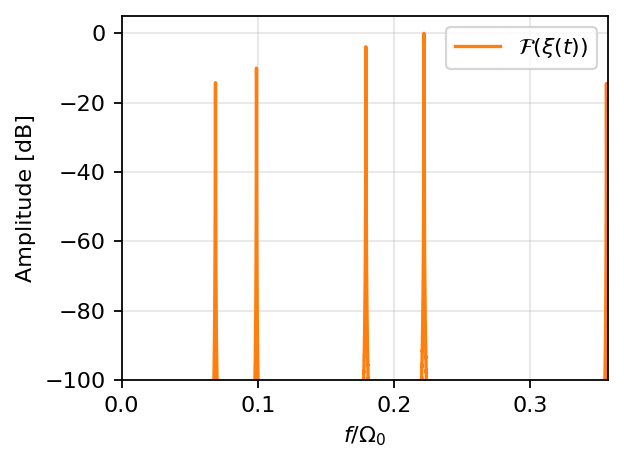

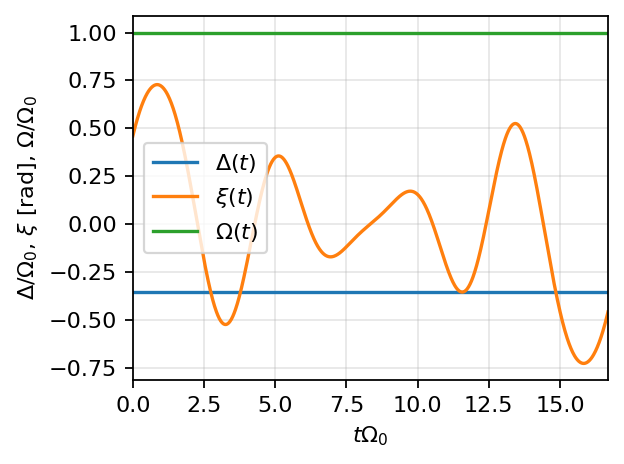

In [6]:
ro.characterization.plot_spectrum(pulse_ansatz, optimized_params)
fig, ax = ro.characterization.plot_pulse(pulse_ansatz, optimized_params)

## Parametrization of Parity Gates in the Target Phase

Here, we aim to optimize the parity gate over a range of target gate phases. To this end, we express the trainable parameters of the laser phase ansatz as polynomial functions of $\theta=4\gamma$. We begin by defining a family of parity gates with different target phases and subsequently redefine the pulse using a polynomial parameter map. Duration and other pulse parameters can be treated analogously by assigning them nonzero polynomial degrees.

In [7]:
phases = np.linspace(0.1, 0.25, 4) * np.pi
opt_results = [opt_result]

gates = [
    ro.gates.ThreeQubitGateIsosceles(
        phi=None,
        theta=4 * phase,
        theta_prime=4 * phase,
        lamb=-8 * phase,
        Vnn=32,
        Vnnn=32,
        decay=1e-4,
    )
    for phase in phases
]

gate_family = ro.gates.ParametrizedGate(
    gates=gates,
    reduction="mean",
)


# --------------------------------------------------
# Pulse ansatz (CRAB + polynomial mapping)
# --------------------------------------------------
degrees = [0, 0, 3, 0]
num_params = [1, 1, n_params, 1]

phase_poly_coeffs_init = 0.1 * np.random.random((n_params, degrees[2] + 1))
phase_poly_coeffs_init[:, 0] = optimized_params[2]

duration_poly_coeffs_init = 0.1 * np.random.random(degrees[0] + 1)
duration_poly_coeffs_init[0] = optimized_params[0]

pulse_mal = ro.pulses.PolynomialPulseMap(degrees=degrees, num_params=num_params)
pulse = ro.pulses.MappedPulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    pulse_map=pulse_mal,
)

With all components in place, we now proceed to the optimization. The parameters obtained from the fixed–target-phase optimization are used as the initial guess for the multi–target-phase optimization. Finally, we evaluate the individual properties of each gate in the resulting gate family and visualize the corresponding optimal pulses.

Started optimization using 4 processes



proc02:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc03:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc00:   0%|                                           | 0/100 [00:00<?, ?it/s]

proc01:   0%|                                           | 0/100 [00:00<?, ?it/s]


=== Optimization finished using multi-start Adam ===

Runtime: 616.965 seconds
Gates with infidelity below tol=1.0e-06: 0

Best gate:
> infidelity = 1.538531e-03
> parameters = (19.640566138481855, [0.4846216], [ 1.1719238   0.35762409  1.00590209  0.00495842  0.74610989  0.55323004
  0.16905695  0.18772389  0.89592469  0.89754808  0.80169379  0.84595574
  0.70426948  0.75193454  0.23831818  0.65866916  0.81784966  0.91017112
  0.73933924  1.03506433  0.48903971  0.50978923 -0.06011433  0.16672985
  1.64220684  0.41283469  0.56414186 -0.0981476   0.12018103  0.20817417
  0.16990143  0.64047418 -0.07418826  0.98843554  0.64612967  0.55901662
  0.07078188 -0.03171536  0.0349618   0.06987585], [])
> duration = 19.640566138481855

=== Performance analysis of the best/fastest optimized gate pulse ===

Target phase:                0.40
Gate infidelity:             1.6574e-03
Gate infidelity (no decay):  8.2860e-04
Rydberg time:                8.2992

Target phase:                0.60
Gate i

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$t \\Omega_0$', ylabel='$\\xi$ [rad]'>)

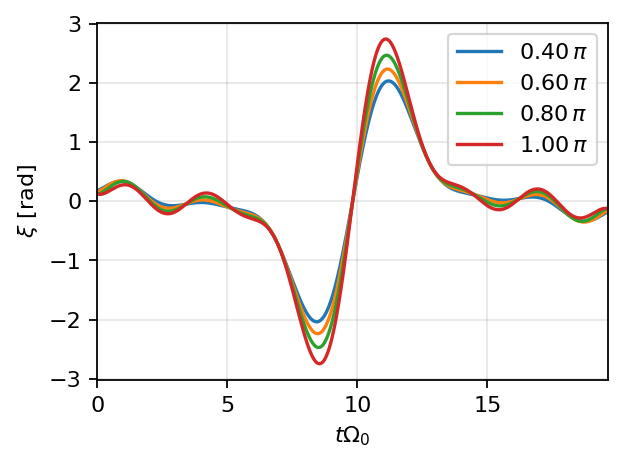

In [11]:
min_initial_params = (
    [15.0, *[0.0] * degrees[0]],
    [-1.0],
    phase_poly_coeffs_init,
    [],
)

max_initial_params = (
    [20.0, *[0.0] * degrees[0]],
    [1.0],
    phase_poly_coeffs_init + 1.0,
    [],
)

opt_result_gate_family = ro.optimization.multi_start_optimize(
    gate_family,
    pulse,
    min_initial_params,
    max_initial_params,
    tol=1e-6,
    num_initializations=400,
    num_steps=100,
    num_processes=4,
    return_history=True,
)

optimized_params_gate_family = opt_result_gate_family.params

print("\n=== Performance analysis of the best/fastest optimized gate pulse ===\n")
for gate in gate_family.gates:
    infidelity, infidelity_nodecay, ryd_time = ro.characterization.analyze_gate(
        gate, pulse, optimized_params_gate_family, tol=1e-6
    )

    # Print the gate performance measures
    print(f"Target phase:                {pulse.target_phase(gate) * 2:.2f}")
    print(f"Gate infidelity:             {infidelity:.4e}")
    print(f"Gate infidelity (no decay):  {infidelity_nodecay:.4e}")
    print(f"Rydberg time:                {ryd_time:.4f}\n")

ro.characterization.plot_mapped_pulse(
    pulse, optimized_params_gate_family, gate_family, plot_detuning=False, plot_rabi=False
)